## load notebook - export excel: for each load - bus, weight, 48-load profile

In [1]:
import pandas as pd
import numpy as np

In [2]:
load_weights = pd.read_csv('../data/Inputs_prepared/loads.csv')
load_weights = load_weights.rename(columns={'load_weight':'Weight', 'bus_name': 'Bus_name'})
load_weights = load_weights[['LoadID', 'Bus_name', 'Weight']]
load_weights

,LoadID,Bus_name,Weight
0,1,way/92419253-275,0.002569
1,2,way/1190395478-220,0.000261
2,3,way/262523325-400,0.000241
3,4,way/49499923-400,0.004041
4,5,way/25935453-400,0.003187
...,...,...,...
380,381,GB71-275,0.001419
381,382,GB52-400,0.005545
382,383,way/87464485-400,0.004038
383,384,way/87464485-400,0.004038


In [3]:
date = '2024-03-31'
demand = pd.read_excel('../data/Inputs_prepared/366days_national_data.xlsx', sheet_name=date)

df_demand = demand.set_index('Variable')
df_demand = df_demand.loc['Demand']
df_demand

df_load = load_weights.set_index('LoadID')['Weight']

profiles = np.outer(df_load.values, df_demand.values)
df_load_profile = pd.DataFrame(
    profiles,
    index=df_load.index,        # LoadID
    columns=df_demand.index    # T1..T48
)

df_load_profile

,T1,T2,T3,T4,T5,T6,T7,T8,T9,T10,...,T39,T40,T41,T42,T43,T44,T45,T46,T47,T48
LoadID,,,,,,,,,,,,,,,,,,,,,
1,56.317717,56.939331,55.566814,54.194297,52.821780,51.933026,51.252333,50.653837,50.751446,50.589621,...,72.276758,71.257003,69.158413,66.705350,63.872125,60.165559,56.803192,55.007704,54.318449,53.629194
2,5.713414,5.776476,5.637235,5.497994,5.358752,5.268588,5.199532,5.138815,5.148717,5.132300,...,7.332453,7.228999,7.016098,6.767236,6.479806,6.103776,5.762665,5.580513,5.510589,5.440664
3,5.273467,5.331673,5.203154,5.074634,4.946115,4.862894,4.799155,4.743114,4.752253,4.737100,...,6.767836,6.672349,6.475841,6.246142,5.980845,5.633770,5.318926,5.150800,5.086260,5.021719
4,88.606489,89.584495,87.425069,85.265644,83.106219,81.707913,80.636957,79.695323,79.848895,79.594290,...,113.715366,112.110952,108.809173,104.949688,100.492085,94.660424,89.370303,86.545403,85.460976,84.376548
5,69.869143,70.640333,68.937554,67.234776,65.531998,64.429388,63.584904,62.842394,62.963490,62.762726,...,89.668321,88.403188,85.799626,82.756295,79.241328,74.642870,70.471436,68.243909,67.388802,66.533695
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381,31.101906,31.445197,30.687214,29.929231,29.171247,28.680426,28.304508,27.973983,28.027889,27.938520,...,39.915413,39.352245,38.193283,36.838559,35.273888,33.226907,31.370014,30.378441,29.997794,29.617148
382,121.578839,122.920781,119.957788,116.994794,114.031801,112.113157,110.643675,109.351640,109.562358,109.213009,...,156.031260,153.829809,149.299369,144.003688,137.887316,129.885571,122.626885,118.750779,117.262813,115.774847
383,88.537447,89.514691,87.356948,85.199205,83.041463,81.644247,80.574125,79.633225,79.786677,79.532270,...,113.626759,112.023595,108.724389,104.867912,100.413782,94.586665,89.300666,86.477967,85.394385,84.310802


## Save

In [4]:
with pd.ExcelWriter("Load.xlsx") as writer:
    load_weights.to_excel(writer, sheet_name="load_weights", index=False)
    df_load_profile.to_excel(writer, sheet_name=f"{date}", index=True)

1. + region
2. plot 
load weight small -> large
color deep-> shallow 

## Add Regions

In [5]:
bus = pd.read_csv('../data/Inputs_prepared/Buses.csv')
bus

,BusID,bus_name,voltage,x,y,RegionName,color
0,1,GB1-220,220.0,-2.895746,58.256815,NaN,red
1,2,GB10-275,275.0,-3.719714,56.088133,Devonside,green
2,3,GB11-275,275.0,-3.179692,55.924620,Whitehouse,red
3,4,GB12-275,275.0,-3.178627,55.903134,Kaimes,red
4,5,GB13-400,400.0,-2.938918,55.884694,Cockenzie,green
...,...,...,...,...,...,...,...
539,540,way/447748328,NaN,-0.136906,51.539316,Added,red
540,541,way/675153143,NaN,0.271833,51.197375,Added,red
541,542,way/1132374248,NaN,-0.136468,51.461563,Added,red
542,543,way/1393615422,NaN,-0.183128,51.446823,Added,red


In [6]:
from shapely.geometry import Point
import geopandas as gpd

regions = gpd.read_file('./ref-nuts-2021-01m.geojson/NUTS_RG_01M_2021_4326_LEVL_3.geojson')
geometry_buses = [Point(xy) for xy in zip(bus['x'], bus['y'])]
gdf_buses = gpd.GeoDataFrame(bus, geometry=geometry_buses, crs="EPSG:4326")

gdf_buses = gdf_buses.to_crs(regions.crs)

gdf_buses

,BusID,bus_name,voltage,x,y,RegionName,color,geometry
0,1,GB1-220,220.0,-2.895746,58.256815,NaN,red,POINT (-2.89575 58.25681)
1,2,GB10-275,275.0,-3.719714,56.088133,Devonside,green,POINT (-3.71971 56.08813)
2,3,GB11-275,275.0,-3.179692,55.924620,Whitehouse,red,POINT (-3.17969 55.92462)
3,4,GB12-275,275.0,-3.178627,55.903134,Kaimes,red,POINT (-3.17863 55.90313)
4,5,GB13-400,400.0,-2.938918,55.884694,Cockenzie,green,POINT (-2.93892 55.88469)
...,...,...,...,...,...,...,...,...
539,540,way/447748328,NaN,-0.136906,51.539316,Added,red,POINT (-0.13691 51.53932)
540,541,way/675153143,NaN,0.271833,51.197375,Added,red,POINT (0.27183 51.19738)
541,542,way/1132374248,NaN,-0.136468,51.461563,Added,red,POINT (-0.13647 51.46156)
542,543,way/1393615422,NaN,-0.183128,51.446823,Added,red,POINT (-0.18313 51.44682)


In [7]:
buses_with_regions = gpd.sjoin(gdf_buses, regions, how="left", predicate='within')
buses_with_regions = buses_with_regions[['BusID', 'bus_name', 'NUTS_NAME']]
buses_with_regions

,BusID,bus_name,NUTS_NAME
0,1,GB1-220,NaN
1,2,GB10-275,Clackmannanshire and Fife
2,3,GB11-275,"Edinburgh, City of"
3,4,GB12-275,"Edinburgh, City of"
4,5,GB13-400,East Lothian and Midlothian
...,...,...,...
539,540,way/447748328,Camden and City of London
540,541,way/675153143,West Kent
541,542,way/1132374248,Lambeth
542,543,way/1393615422,Wandsworth


In [8]:
bus_region_map = buses_with_regions.set_index('bus_name')['NUTS_NAME'].to_dict()
load_weights['Region'] = load_weights['Bus_name'].map(bus_region_map)
load_weights

,LoadID,Bus_name,Weight,Region
0,1,way/92419253-275,0.002569,Cheshire East
1,2,way/1190395478-220,0.000261,Aberdeen City and Aberdeenshire
2,3,way/262523325-400,0.000241,East Lothian and Midlothian
3,4,way/49499923-400,0.004041,Warwickshire
4,5,way/25935453-400,0.003187,Cambridgeshire CC
...,...,...,...,...
380,381,GB71-275,0.001419,Cardiff and Vale of Glamorgan
381,382,GB52-400,0.005545,Lincolnshire
382,383,way/87464485-400,0.004038,Hertfordshire
383,384,way/87464485-400,0.004038,Hertfordshire


## Plot Figure

In [9]:
# Aggregate loads by region

load_by_region = (
    load_weights.groupby('Region', as_index=False)['Weight']
         .sum()
         .rename(columns={'Weight': 'TotalWeight'})
)

regions_load = regions.merge(
    load_by_region,
    left_on='NUTS_NAME',
    right_on='Region',
    how='left'
)

In [21]:
regions_load['TotalWeight'] = regions_load['TotalWeight'].fillna(0.0)
regions_load = regions_load[regions_load['CNTR_CODE'] == 'UK']
regions_load

regions_load
regions_load[regions_load['TotalWeight'] == 0.0000000]

,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry,Region,TotalWeight
1101,UKK14,3,UK,Swindon,Swindon,4,2,2,"MULTIPOLYGON (((-1.69076 51.66327, -1.68902 51...",NaN,0.0
1103,UKF14,3,UK,Nottingham,Nottingham,4,1,3,"POLYGON ((-1.18275 53.01857, -1.18443 53.01446...",NaN,0.0
1113,UKM65,3,UK,Orkney Islands,Orkney Islands,4,3,1,"MULTIPOLYGON (((-2.38243 59.39237, -2.37134 59...",NaN,0.0
1120,UKF21,3,UK,Leicester,Leicester,4,1,3,"POLYGON ((-1.15808 52.69107, -1.15235 52.68903...",NaN,0.0
1126,UKK41,3,UK,Plymouth,Plymouth,4,1,1,"MULTIPOLYGON (((-4.10671 50.43487, -4.107 50.4...",NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1502,UKI72,3,UK,Brent,Brent,4,1,2,"POLYGON ((-0.25301 51.5889, -0.24822 51.58436,...",NaN,0.0
1504,UKI74,3,UK,Harrow and Hillingdon,Harrow and Hillingdon,4,1,2,"POLYGON ((-0.30389 51.63147, -0.28751 51.61715...",NaN,0.0
1505,UKI75,3,UK,Hounslow and Richmond upon Thames,Hounslow and Richmond upon Thames,4,1,1,"POLYGON ((-0.27979 51.50211, -0.27784 51.49948...",NaN,0.0
1507,UKN08,3,UK,"Newry, Mourne and Down","Newry, Mourne and Down",4,3,1,"MULTIPOLYGON (((-5.8173 54.49184, -5.80878 54....",NaN,0.0


1. +62 buses, no loads, no units
 
2. 1 year profile -> aria report 4,72, 4.73 a

3. + //// represents no loads

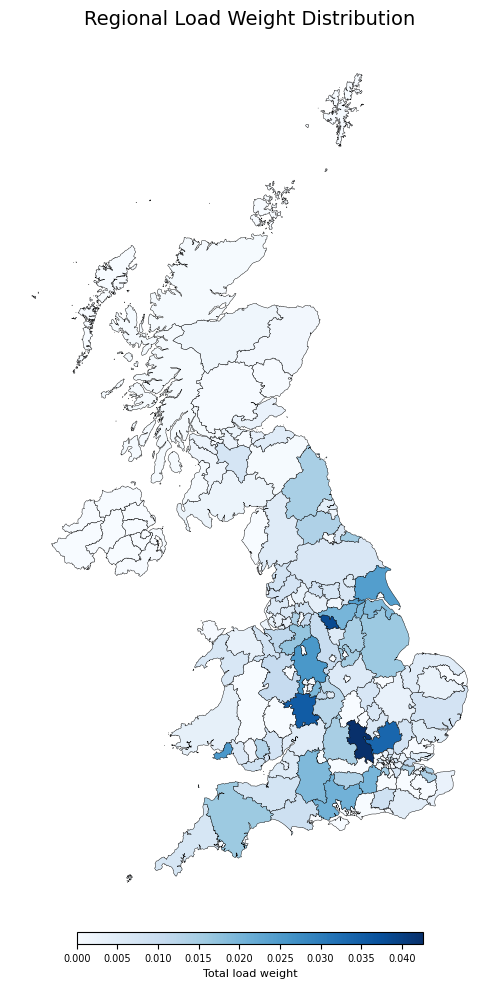

In [11]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(8, 10))

regions_load.plot(
    column='TotalWeight',
    ax=ax,
    legend=False,
    cmap='Blues',
    edgecolor='black',
    linewidth=0.3,
    missing_kwds={"color": "lightgrey", "hatch": "///", "label": "No load data"}
)

ax.set_title("Regional Load Weight Distribution", fontsize=14)
ax.set_axis_off()

vmin = regions_load['TotalWeight'].min()
vmax = regions_load['TotalWeight'].max()

norm = colors.Normalize(vmin=vmin, vmax=vmax)
sm = cm.ScalarMappable(norm=norm, cmap='Blues')
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation='horizontal',
    fraction=0.02,    # 更薄
    pad=0.01,         # 更靠近
    shrink=0.45,      # 缩短长度
    aspect=30         # 拉长但更细
)

cbar.set_label('Total load weight', fontsize=8)
cbar.ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()
